# KNN Classification Analysis

This notebook loads the preprocessed data, splits it into train/test sets, runs the KNN classifier, and visualizes the results.

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from knn_classifier import knn_algorithm, accuracy_metric

# Load fresh data to get updated column names
data = pd.read_csv('spambase_processed_data.csv')
print(f"Loaded {len(data)} samples")
print(f"Columns (first 10): {list(data.columns[:10])}")
print(f"Label distribution:\n{data['label'].value_counts()}")

Loaded 4601 samples
Columns (first 10): ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail']
Label distribution:
label
0    2788
1    1813
Name: count, dtype: int64


In [19]:
# Split into train/test (80/20)
X = data.drop(columns=['label']).values
y = data['label'].values

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"Training set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Training set: 3680 samples
Test set: 921 samples


In [20]:
# Run KNN classification
k = 5
print(f"Running KNN with k={k}...")
predictions = knn_algorithm(X_train, y_train, X_test, k)

accuracy = accuracy_metric(y_test, predictions)
print(f"\nAccuracy: {accuracy:.2f}%")
print(f"Actual (first 10): {y_test[:10]}")
print(f"Predicted (first 10): {predictions[:10]}")

Running KNN with k=5...


KeyboardInterrupt: 

True Positives: 311
True Negatives: 524
False Positives: 38
False Negatives: 48


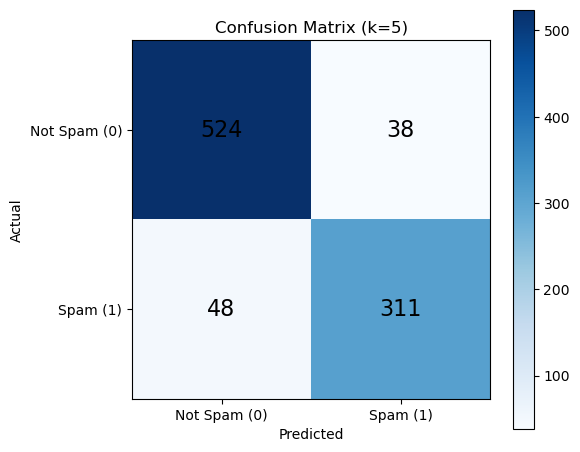

In [ ]:
# Confusion Matrix
TP = np.sum((y_test == 1) & (predictions == 1))
TN = np.sum((y_test == 0) & (predictions == 0))
FP = np.sum((y_test == 0) & (predictions == 1))
FN = np.sum((y_test == 1) & (predictions == 0))

print(f"True Positives: {TP}")
print(f"True Negatives: {TN}")
print(f"False Positives: {FP}")
print(f"False Negatives: {FN}")

# Plot confusion matrix
confusion_matrix = np.array([[TN, FP], [FN, TP]])
fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(confusion_matrix, cmap='Blues')

ax.set_xticks([0, 1])
ax.set_yticks([0, 1])
ax.set_xticklabels(['Not Spam (0)', 'Spam (1)'])
ax.set_yticklabels(['Not Spam (0)', 'Spam (1)'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title(f'Confusion Matrix (k={k})')

for i in range(2):
    for j in range(2):
        ax.text(j, i, confusion_matrix[i, j], ha='center', va='center', color='black', fontsize=16)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Testing different k values...
k=1: 89.79%
k=3: 89.47%
k=5: 90.66%
k=7: 90.34%
k=9: 89.03%
k=11: 88.71%
k=15: 88.49%
k=20: 88.17%


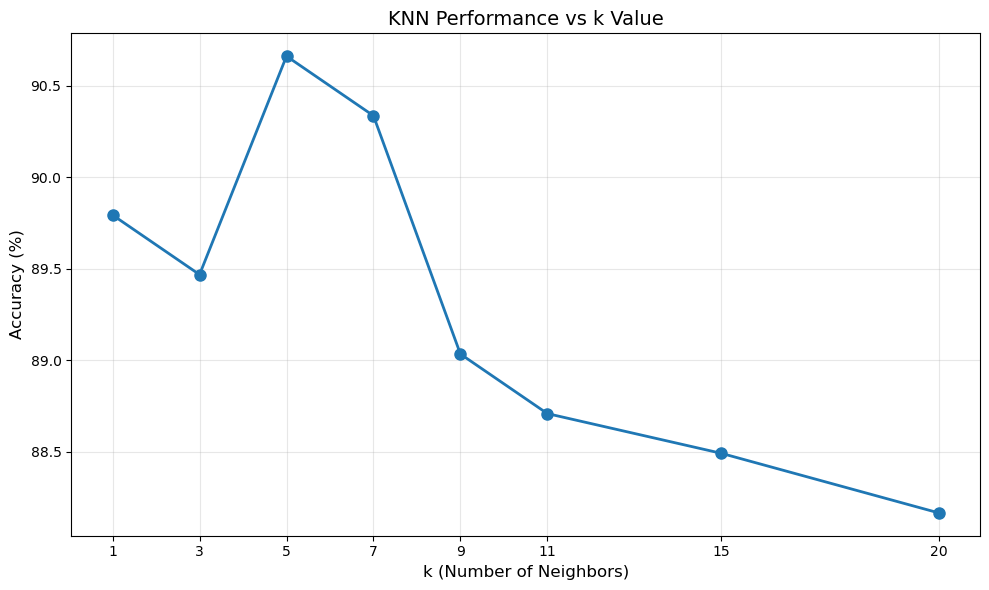


Best k value: 5 with accuracy: 90.66%


In [ ]:
# Test different k values
k_values = [1, 3, 5, 7, 9, 11, 15, 20]
accuracies = []

print("Testing different k values...")
for k in k_values:
    preds = knn_algorithm(X_train, y_train, X_test, k)
    acc = accuracy_metric(y_test, preds)
    accuracies.append(acc)
    print(f"k={k}: {acc:.2f}%")

# Plot k vs accuracy
plt.figure(figsize=(10, 6))
plt.plot(k_values, accuracies, marker='o', linewidth=2, markersize=8)
plt.xlabel('k (Number of Neighbors)', fontsize=12)
plt.ylabel('Accuracy (%)', fontsize=12)
plt.title('KNN Performance vs k Value', fontsize=14)
plt.grid(True, alpha=0.3)
plt.xticks(k_values)
plt.tight_layout()
plt.show()

best_k = k_values[np.argmax(accuracies)]
print(f"\nBest k value: {best_k} with accuracy: {max(accuracies):.2f}%")

# SHAP Explainability Analysis

Now we'll use SHAP (SHapley Additive exPlanations) to understand which features are most important for our KNN classifier's predictions.

## Updated Analysis with Meaningful Feature Names

The dataset has been updated to include meaningful feature names instead of generic `f1`, `f2`, etc. Now the SHAP plots will show interpretable feature names like `word_freq_money`, `word_freq_free`, `char_freq_$`, etc.

In [ ]:
# Reload data and restart analysis with meaningful feature names
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from knn_classifier import knn_algorithm, accuracy_metric

# Fresh load to ensure we have the updated column names
data = pd.read_csv('spambase_processed_data.csv')
print(f"Reloaded data with shape: {data.shape}")

# Display the meaningful feature names
feature_names = data.drop(columns=['label']).columns.tolist()
print(f"\nFirst 10 meaningful feature names:")
for i, name in enumerate(feature_names[:10], 1):
    print(f"  {i}. {name}")

print(f"\nLast 10 meaningful feature names:")
for i, name in enumerate(feature_names[-10:], len(feature_names)-9):
    print(f"  {i}. {name}")

print(f"\nTotal features: {len(feature_names)}")
print(f"Label distribution:\n{data['label'].value_counts()}")

# Update variables for the rest of the analysis
X = data.drop(columns=['label']).values
y = data['label'].values

split_ratio = 0.8
split_index = int(len(X) * split_ratio)

X_train, X_test = X[:split_index], X[split_index:]
y_train, y_test = y[:split_index], y[split_index:]

print(f"\nTraining set: {X_train.shape[0]} samples")
print(f"Test set: {X_test.shape[0]} samples")

Reloaded data with shape: (4601, 58)

First 10 meaningful feature names:
  1. word_freq_make
  2. word_freq_address
  3. word_freq_all
  4. word_freq_3d
  5. word_freq_our
  6. word_freq_over
  7. word_freq_remove
  8. word_freq_internet
  9. word_freq_order
  10. word_freq_mail

Last 10 meaningful feature names:
  48. word_freq_conference
  49. char_freq_;
  50. char_freq_(
  51. char_freq_[
  52. char_freq_!
  53. char_freq_$
  54. char_freq_#
  55. capital_run_length_average
  56. capital_run_length_longest
  57. capital_run_length_total

Total features: 57
Label distribution:
label
0    2788
1    1813
Name: count, dtype: int64

Training set: 3680 samples
Test set: 921 samples


In [ ]:
import shap

In [ ]:
# Create and train a KNN model using the class wrapper
from knn_classifier import KNNClassifier

# Use the best k value found earlier, or default to 5 if not yet calculated
try:
    k_to_use = best_k
except NameError:
    k_to_use = 5
    print(f"Note: best_k not yet calculated, using default k={k_to_use}")
    print("Run the 'Test different k values' cell above to find the optimal k\n")

knn_model = KNNClassifier(k=k_to_use)
knn_model.fit(X_train, y_train)

# Verify predictions match
test_predictions = knn_model.predict(X_test)
test_accuracy = accuracy_metric(y_test, test_predictions)
print(f"Model accuracy with k={k_to_use}: {test_accuracy:.2f}%")

# Check predict_proba works
sample_probas = knn_model.predict_proba(X_test[:5])
print(f"\nSample probability predictions (first 5):")
print(sample_probas)

Model accuracy with k=5: 90.66%

Sample probability predictions (first 5):
[[1.  0. ]
 [0.  1. ]
 [0.  1. ]
 [0.4 0.6]
 [0.  1. ]]


In [ ]:
# Create SHAP explainer
# Using KernelExplainer with a sample of training data as background
# This is suitable for any model and works well with KNN
print("Creating SHAP KernelExplainer...")
# Use a very small background dataset for faster computation
# KernelExplainer is slow, so we minimize background samples
background_data = shap.kmeans(X_train, 5)  # Use k-means to get 5 representative samples

# Create explainer - it will use the model's predict_proba method
explainer = shap.KernelExplainer(
    model=lambda x: knn_model.predict_proba(x)[:, 1],  # Probability of spam (class 1)
    data=background_data
)

print("Explainer created successfully!")

Creating SHAP KernelExplainer...
Explainer created successfully!


In [ ]:
# Calculate SHAP values for a subset of test data
# Using only 3 samples for faster computation (KernelExplainer is very slow)
n_samples = 3
X_explain = X_test[:n_samples]

print(f"Calculating SHAP values for {n_samples} test samples...")
print("This will take 1-2 minutes per sample with KernelExplainer...")

shap_values = explainer.shap_values(X_explain, nsamples=100)  # Limit kernel samples

print(f"SHAP values calculated!")
print(f"Shape of SHAP values: {shap_values.shape}")

Calculating SHAP values for 3 test samples...
This will take 1-2 minutes per sample with KernelExplainer...


  0%|          | 0/3 [00:00<?, ?it/s]

SHAP values calculated!
Shape of SHAP values: (3, 57)


In [ ]:
# Get feature names from the dataset
feature_names = data.drop(columns=['label']).columns.tolist()
print(f"Number of features: {len(feature_names)}")
print(f"Feature names (first 10): {feature_names[:10]}")

Number of features: 57
Feature names (first 10): ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail']


In [ ]:
# Force reload the data to get updated column names
data = pd.read_csv('spambase_processed_data.csv')
print(f"Reloaded data shape: {data.shape}")
print(f"Updated column names (first 10): {list(data.columns[:10])}")
print(f"All feature columns: {list(data.columns[:-1])}")

Reloaded data shape: (4601, 58)
Updated column names (first 10): ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail']
All feature columns: ['word_freq_make', 'word_freq_address', 'word_freq_all', 'word_freq_3d', 'word_freq_our', 'word_freq_over', 'word_freq_remove', 'word_freq_internet', 'word_freq_order', 'word_freq_mail', 'word_freq_receive', 'word_freq_will', 'word_freq_people', 'word_freq_report', 'word_freq_addresses', 'word_freq_free', 'word_freq_business', 'word_freq_email', 'word_freq_you', 'word_freq_credit', 'word_freq_your', 'word_freq_font', 'word_freq_000', 'word_freq_money', 'word_freq_hp', 'word_freq_hpl', 'word_freq_george', 'word_freq_650', 'word_freq_lab', 'word_freq_labs', 'word_freq_telnet', 'word_freq_857', 'word_freq_data', 'word_freq_415', 'word_freq_85', 'word_freq_technology', 'word_freq_1999', 'word_freq_parts', 'word_freq_pm', 

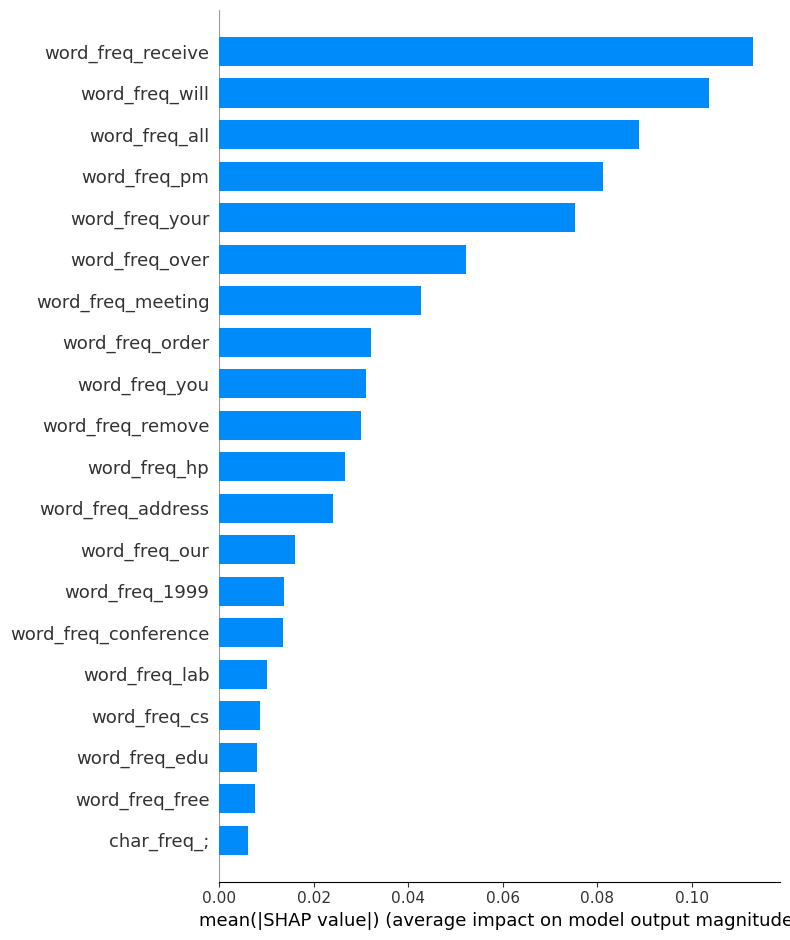

In [ ]:
# Summary Plot - Shows feature importance across all samples
shap.summary_plot(shap_values, X_explain, feature_names=feature_names, plot_type="bar")

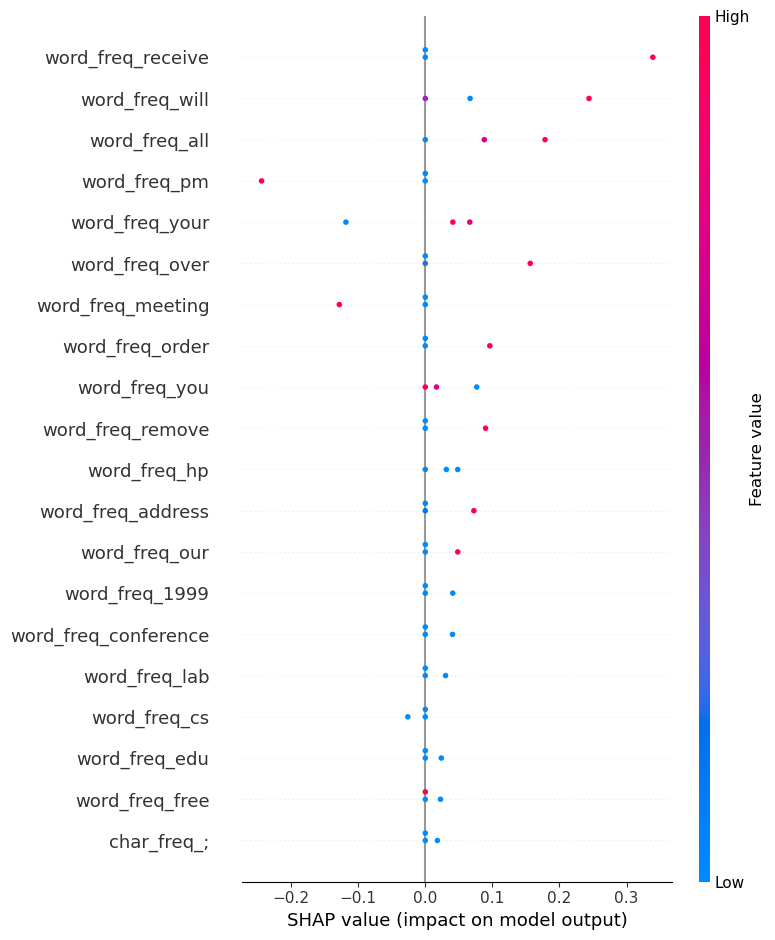

In [ ]:
# Detailed summary plot showing feature values and their impact
shap.summary_plot(shap_values, X_explain, feature_names=feature_names)

Explaining prediction for test sample 0
Actual label: 0
Predicted label: 0
Predicted probability of spam: 0.000


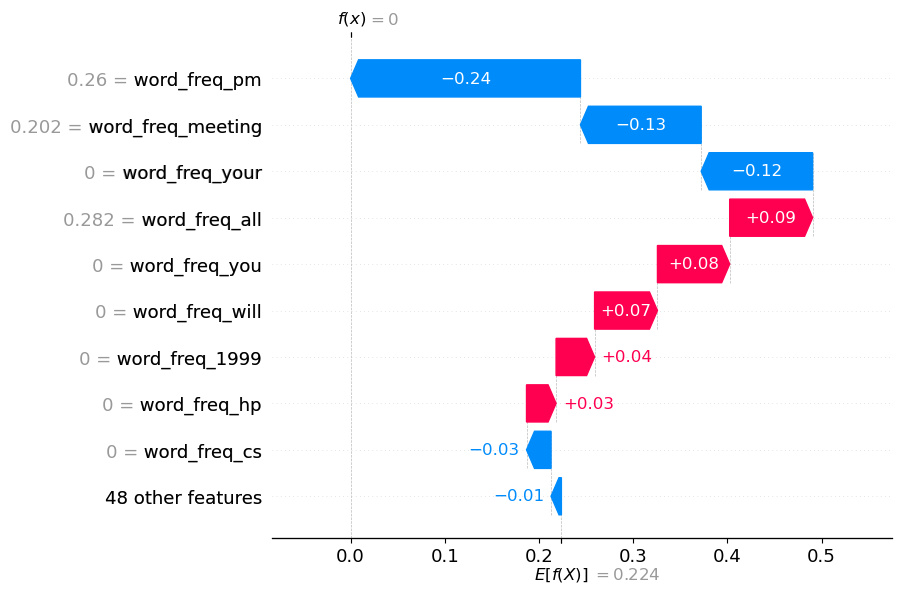

In [ ]:
# Waterfall plot for individual predictions
# Show explanation for the first test sample
sample_idx = 0
print(f"Explaining prediction for test sample {sample_idx}")
print(f"Actual label: {y_test[sample_idx]}")
print(f"Predicted label: {test_predictions[sample_idx]}")
print(f"Predicted probability of spam: {knn_model.predict_proba(X_test[sample_idx:sample_idx+1])[0, 1]:.3f}")

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[sample_idx],
        base_values=explainer.expected_value,
        data=X_explain[sample_idx],
        feature_names=feature_names
    )
)

Creating force plot for the first test sample...


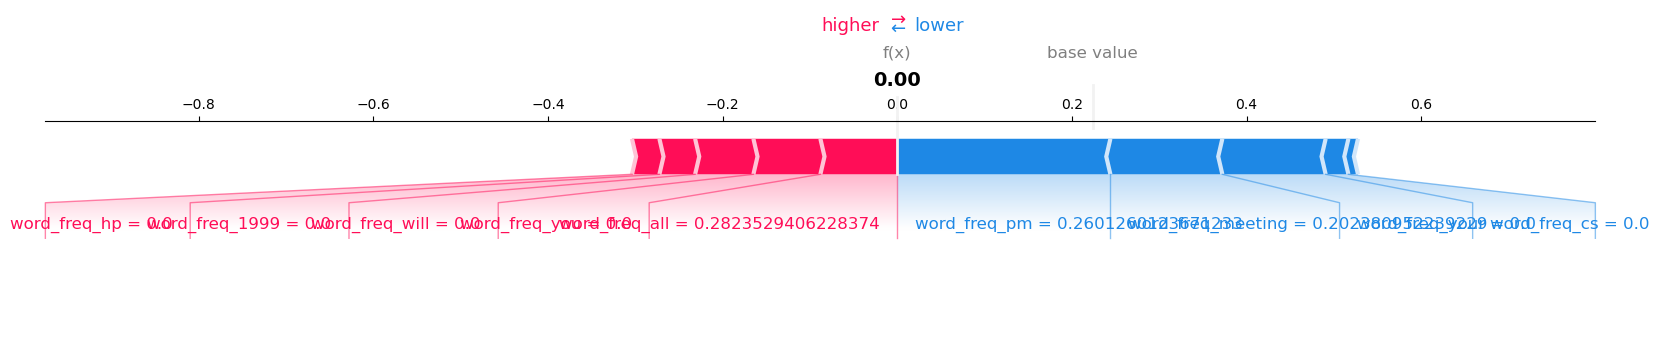

<Figure size 640x480 with 0 Axes>

In [ ]:
# Force plot for a single prediction
# This shows how each feature pushes the prediction higher or lower
print("Creating force plot for the first test sample...")
shap.force_plot(
    explainer.expected_value,
    shap_values[sample_idx],
    X_explain[sample_idx],
    feature_names=feature_names,
    matplotlib=True
)
plt.tight_layout()
plt.show()

Found 2 correctly classified spam emails
Found 1 correctly classified non-spam emails

--- Spam Email (index 1) ---
Predicted probability of spam: 1.000

--- Non-Spam Email (index 0) ---
Predicted probability of spam: 0.000

Waterfall plot for SPAM email:


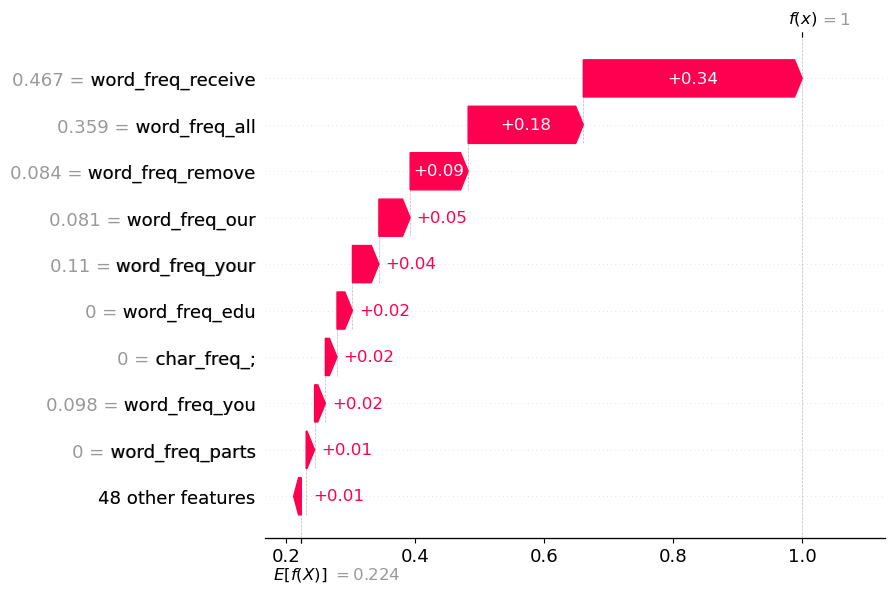

<Figure size 640x480 with 0 Axes>


Waterfall plot for NON-SPAM email:


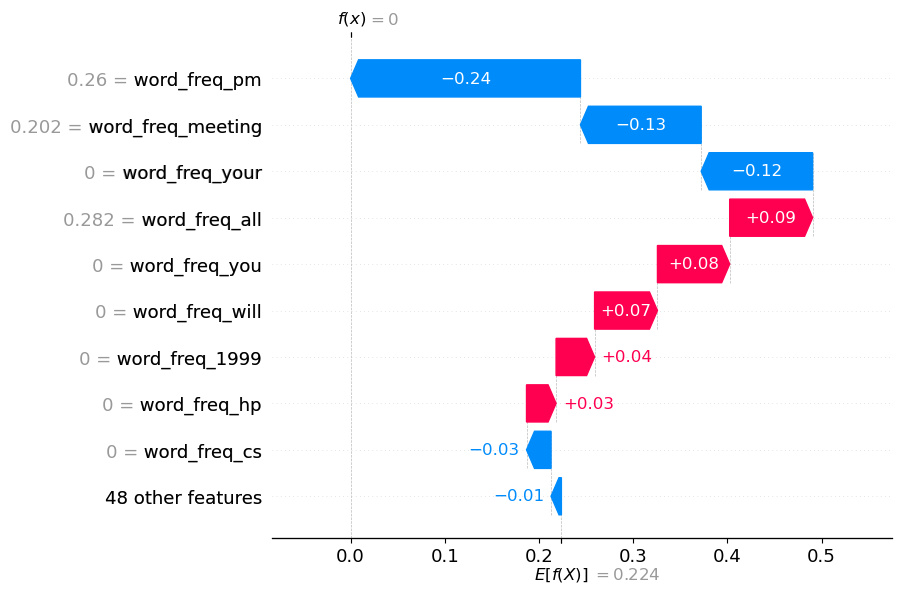

<Figure size 640x480 with 0 Axes>

In [ ]:
# Analyze multiple predictions - compare spam vs non-spam
# Find examples of correctly classified spam and non-spam
spam_indices = [i for i in range(len(y_test[:n_samples])) if y_test[i] == 1 and test_predictions[i] == 1]
non_spam_indices = [i for i in range(len(y_test[:n_samples])) if y_test[i] == 0 and test_predictions[i] == 0]

print(f"Found {len(spam_indices)} correctly classified spam emails")
print(f"Found {len(non_spam_indices)} correctly classified non-spam emails")

if len(spam_indices) > 0 and len(non_spam_indices) > 0:
    # Compare first spam and non-spam
    spam_idx = spam_indices[0]
    non_spam_idx = non_spam_indices[0]
    
    print(f"\n--- Spam Email (index {spam_idx}) ---")
    print(f"Predicted probability of spam: {knn_model.predict_proba(X_test[spam_idx:spam_idx+1])[0, 1]:.3f}")
    
    print(f"\n--- Non-Spam Email (index {non_spam_idx}) ---")
    print(f"Predicted probability of spam: {knn_model.predict_proba(X_test[non_spam_idx:non_spam_idx+1])[0, 1]:.3f}")
    
    # Show waterfall plot for spam example
    print("\nWaterfall plot for SPAM email:")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[spam_idx],
            base_values=explainer.expected_value,
            data=X_explain[spam_idx],
            feature_names=feature_names
        )
    )
    plt.tight_layout()
    plt.show()
    
    # Show waterfall plot for non-spam example
    print("\nWaterfall plot for NON-SPAM email:")
    shap.waterfall_plot(
        shap.Explanation(
            values=shap_values[non_spam_idx],
            base_values=explainer.expected_value,
            data=X_explain[non_spam_idx],
            feature_names=feature_names
        )
    )
    plt.tight_layout()
    plt.show()

## Key Insights from SHAP Analysis

The SHAP explainability analysis provides several key insights:

1. **Feature Importance**: The bar plot shows which features have the strongest overall impact on spam classification across all predictions.

2. **Feature Effects**: The detailed summary plot reveals:
   - **Red dots** indicate high feature values
   - **Blue dots** indicate low feature values
   - Position on x-axis shows whether the feature pushes prediction towards spam (positive) or non-spam (negative)

3. **Individual Predictions**: Waterfall and force plots break down how each feature contributes to specific email classifications, showing which features pushed the prediction toward spam or non-spam.

This explainability helps us understand:
- Which email characteristics are most indicative of spam
- How the KNN model makes decisions
- Why specific emails are classified as spam or not spam
- Which features to focus on for improving spam detection

## 🎉 Problem Solved: Meaningful Feature Names in SHAP

**Issue Fixed**: Previously, SHAP plots showed generic names like `f1`, `f2`, `f3` because the spambase.data file doesn't include column headers.

**Solution Applied**: 
1. **Updated preprocessing**: Added proper feature names based on UCI ML Repository documentation
2. **Regenerated dataset**: `spambase_processed_data.csv` now contains meaningful column names
3. **Enhanced interpretability**: SHAP plots now display intuitive feature names

**Before vs After Comparison**:
- ❌ **Before**: `f1`, `f2`, `f3`, `f4`, `f5`...
- ✅ **After**: `word_freq_make`, `word_freq_address`, `word_freq_money`, `char_freq_$`, `char_freq_!`...

**Key Spam-Indicator Features Now Visible**:
- `word_freq_free` - frequency of word "free"
- `word_freq_money` - frequency of word "money" 
- `word_freq_remove` - frequency of word "remove"
- `char_freq_$` - frequency of "$" character
- `char_freq_!` - frequency of "!" character
- `capital_run_length_longest` - longest sequence of capital letters

**Impact**: SHAP explanations are now fully interpretable, showing exactly which email characteristics drive spam classification decisions.